#Nosso conjunto de dados

In [1]:
import torch
from torchvision import datasets, transforms

import matplotlib.pyplot as plt
import os

from torch.utils.data import Dataset, DataLoader
from torch import nn, optim
from torch.autograd.variable import Variable
import pickle


In [2]:
imgsize = 28
batch_size = 128
DATA_DIR = '/content/drive/MyDrive/datasets'
IMG_DIR = os.path.join(DATA_DIR, 'results')

In [3]:
fashiontransform = transforms.Compose(
    [
        transforms.ToTensor(),
        transforms.Normalize(
            (0.5), (0.5)
            )
    ]
)

fashiondata = datasets.FashionMNIST(DATA_DIR, download=True, transform=fashiontransform)

dataloader = DataLoader(fashiondata,batch_size=batch_size,shuffle=True)

In [4]:
img, label = fashiondata[0]

In [5]:
def lookat_dataset(dataset, pilimg=False):
    figure = plt.figure(figsize=(16, 4))
    rows, cols = 2, 8
    for i in range(1, 17):
        sample_idx = torch.randint(len(dataset), size=(1,)).item()
        img, label = dataset[sample_idx]
        figure.add_subplot(rows, cols, i)
        plt.axis("off")
        if pilimg:
            plt.imshow(img)
        else:
            img = (img.squeeze() * 0.5) + 0.5
            if len(img.shape) == 2:
                plt.imshow(img, cmap='gray')
            else:
                plt.imshow(img.permute(1, 2, 0))
    plt.show()

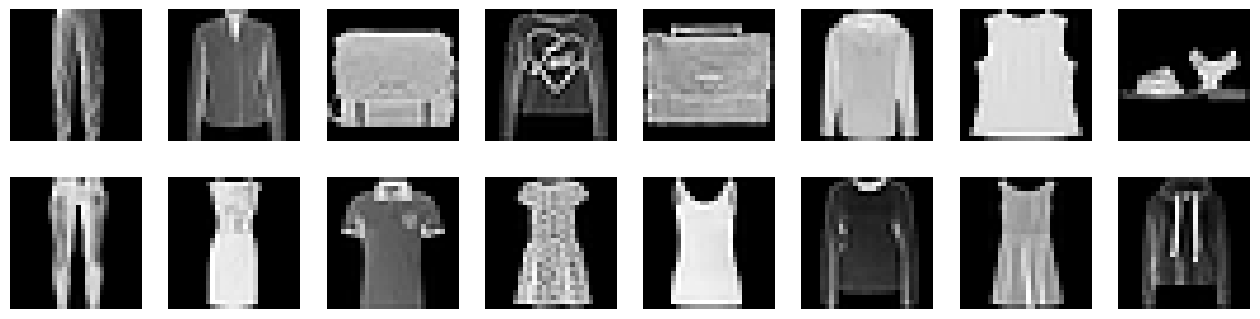

In [6]:
lookat_dataset(fashiondata)

In [47]:
from torch.autograd import forward_ad
class Generator(nn.Module):
  def __init__(self, n_in, n_out):
    super().__init__()

    self.layers = nn.Sequential(
        nn.Linear(n_in,256),
        nn.ReLU(),
        nn.Linear(256,512),
        nn.ReLU(),
        nn.Linear(512,1024),
        nn.ReLU(),
        nn.Linear(1024,n_out),
        nn.Tanh() #permite que os valores fiquem entre -1 e 1
    )
  def forward(self,z):
    return self.layers(z)

class Discriminator(nn.Module):
    def __init__(self, n_in):
        super().__init__()
        n_out = 1

        self.layers = nn.Sequential(
            nn.Linear(n_in, 1024),
            nn.LeakyReLU(0.2),

            nn.Linear(1024, 512),
            nn.LeakyReLU(0.2),

            nn.Linear(512, 256),
            nn.LeakyReLU(0.2),

            torch.nn.Linear(256, n_out),
            torch.nn.Sigmoid()
        )

    def forward(self, x):
        return self.layers(x)


In [48]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Rodando em {device}')

Rodando em cuda


In [50]:
noise_dim = 100
generator = Generator(noise_dim, imgsize * imgsize).to(device)
discriminator = Discriminator(imgsize*imgsize).to(device)

In [51]:
def images_to_vectors(images):
    return images.view(images.size(0), imgsize * imgsize)

def vectors_to_images(vectors, nc=1):
    return vectors.view(vectors.size(0), nc, imgsize, imgsize)

def noise(size, dim = noise_dim, device = device):
  return torch.randn(size, dim).to(device)

def log_images(test_images, savepath=None):
  figure = plt.figure(figsize=(8, 8))
  figure.subplots_adjust(wspace=-0.08, hspace=0.01)
  rows, cols = len(test_images)//4, 4
  for i, img in enumerate(test_images):
      figure.add_subplot(rows, cols, i+1)
      plt.axis("off")
      plt.imshow(img.squeeze(), cmap='gray')

  if savepath is not None:
    figure.savefig(savepath)
  plt.show()

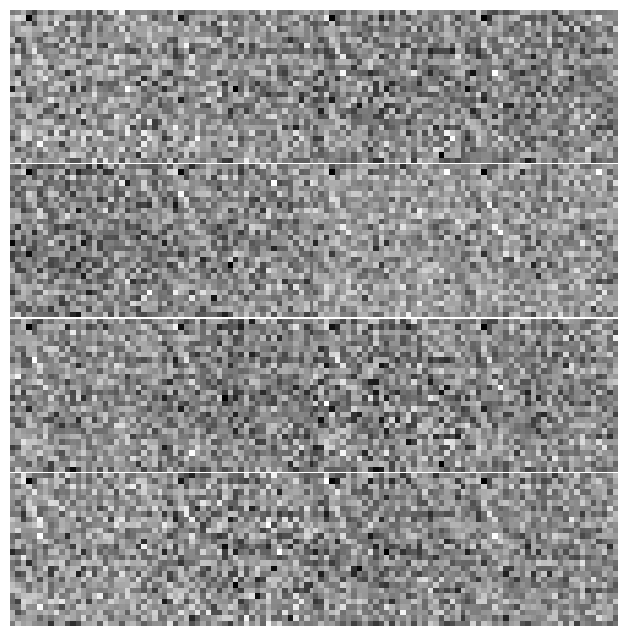

In [52]:
num_test_samples = 16
torch.manual_seed(7777)
test_noise = noise(num_test_samples)
imagens = vectors_to_images(generator(test_noise))
imagepath = os.path.join(IMG_DIR, f'{0}.jpg')
log_images(imagens.cpu().detach().numpy(), imagepath)

In [53]:
def real_data_target(size, device = device):
  return torch.ones(size,1).to(device)

def fake_data_target(size, device = device):
  return torch.zeros(size,1).to(device)

In [54]:
d_optimizer = optim.Adam(discriminator.parameters(), lr = 0.0002)
g_optimizer = optim.Adam(generator.parameters(), lr = 0.0002)
lossfunc = nn.BCELoss()

In [55]:
def train_discriminator(optimizer, real_data, fake_data):
  optimizer.zero_grad() #zero os gradientes acumulados

  # Referente aos dados reais
  pred_real = discriminator(real_data)
  error_real = lossfunc(pred_real, real_data_target(real_data.size(0)))
  error_real.backward()
  #Referente aos dados falsos
  pred_fake = discriminator(fake_data)
  error_fake = lossfunc(pred_fake, fake_data_target(fake_data.size(0)))
  error_fake.backward()

  optimizer.step()

  return error_real + error_fake, pred_real, pred_fake


def train_generator(optimizer, fake_data):
  pred_fake = discriminator(fake_data)
  error_fake = lossfunc(pred_fake, real_data_target(pred_fake.size(0)))
  error_fake.backward()
  optimizer.step()

  return error_fake




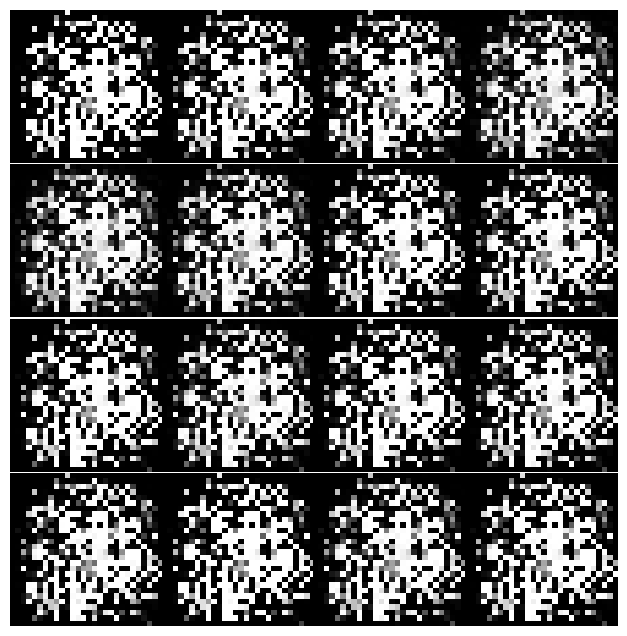

Epoch: 0/10 Losses:
Discriminator: 0.0004; Generator: 13.6865
D(x): 1.0000; D(G(z)): 0.0003


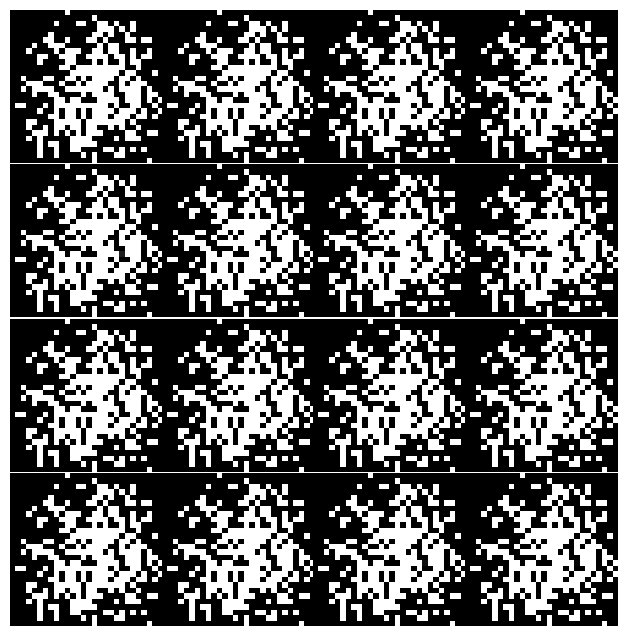

Epoch: 1/10 Losses:
Discriminator: 0.0000; Generator: 11.8924
D(x): 1.0000; D(G(z)): 0.0000


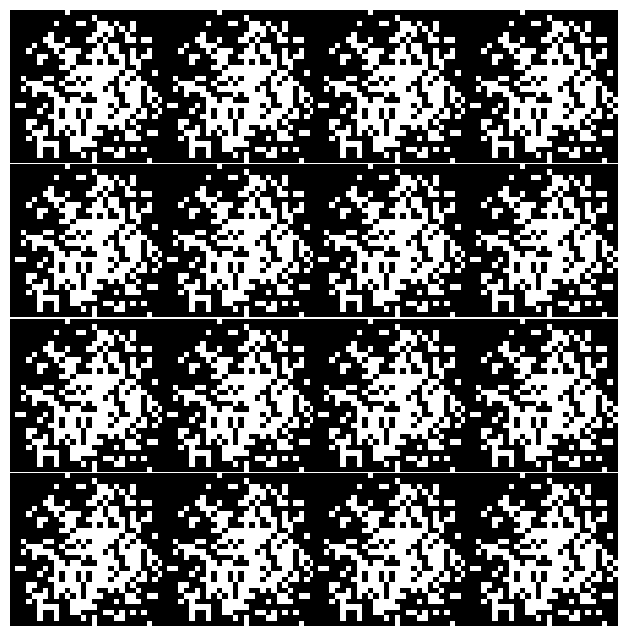

Epoch: 2/10 Losses:
Discriminator: 0.0000; Generator: 15.1141
D(x): 1.0000; D(G(z)): 0.0000


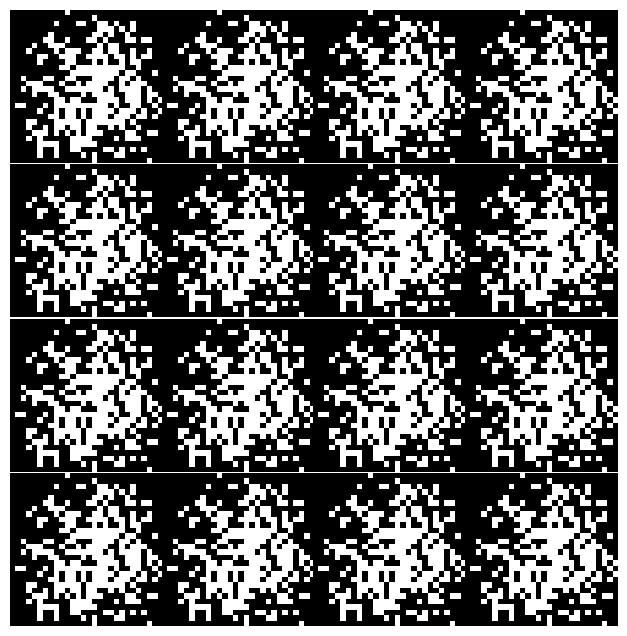

Epoch: 3/10 Losses:
Discriminator: 0.0000; Generator: 15.7199
D(x): 1.0000; D(G(z)): 0.0000


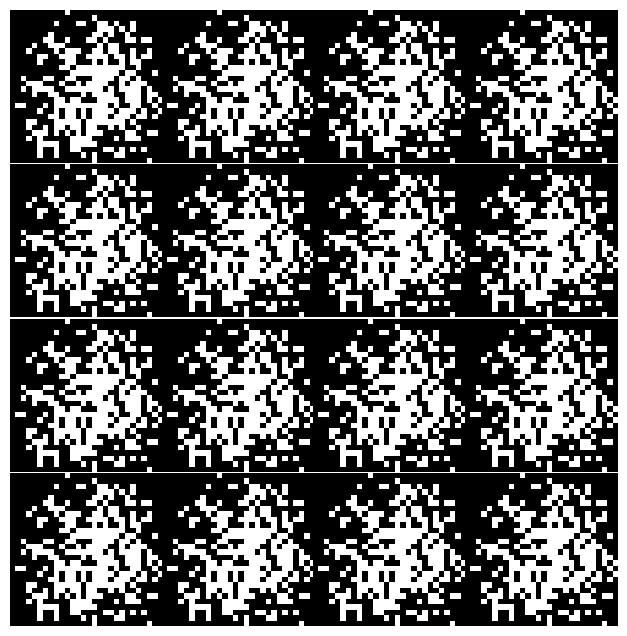

Epoch: 4/10 Losses:
Discriminator: 0.0000; Generator: 16.2708
D(x): 1.0000; D(G(z)): 0.0000


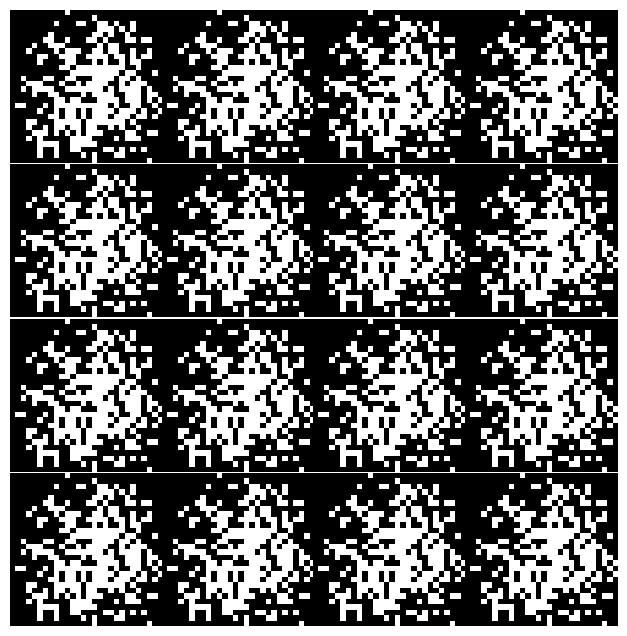

Epoch: 5/10 Losses:
Discriminator: 0.0000; Generator: 16.6127
D(x): 1.0000; D(G(z)): 0.0000


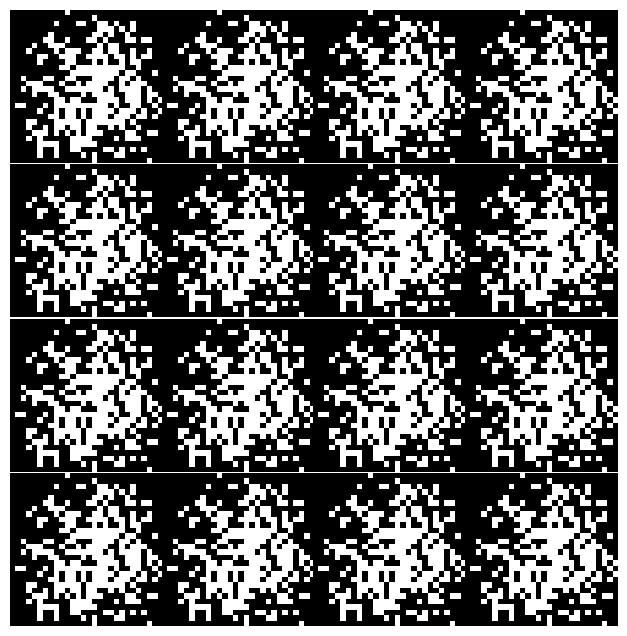

Epoch: 6/10 Losses:
Discriminator: 0.0000; Generator: 17.0090
D(x): 1.0000; D(G(z)): 0.0000


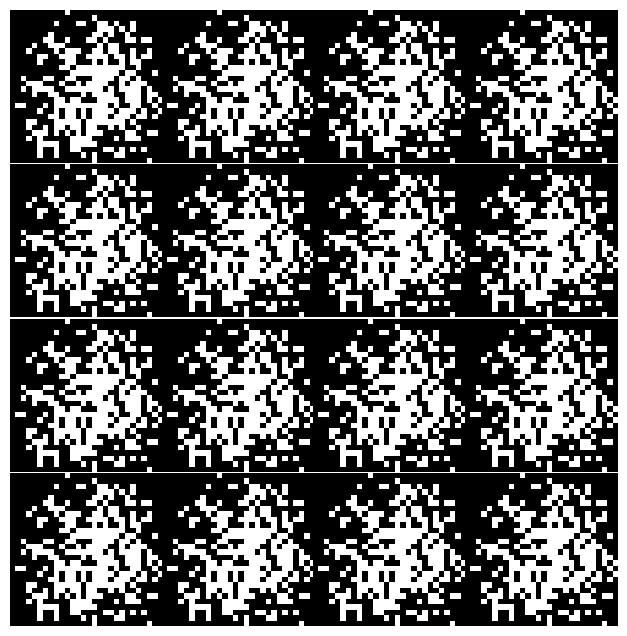

Epoch: 7/10 Losses:
Discriminator: 0.0000; Generator: 17.2981
D(x): 1.0000; D(G(z)): 0.0000


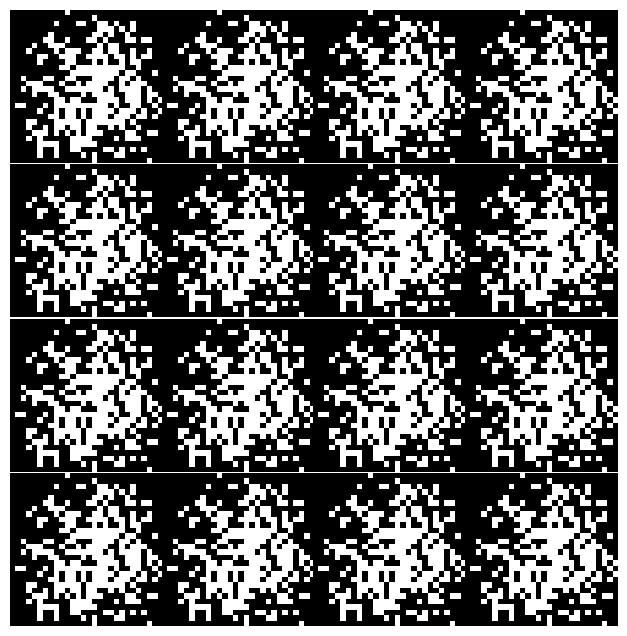

Epoch: 8/10 Losses:
Discriminator: 0.0000; Generator: 17.5128
D(x): 1.0000; D(G(z)): 0.0000


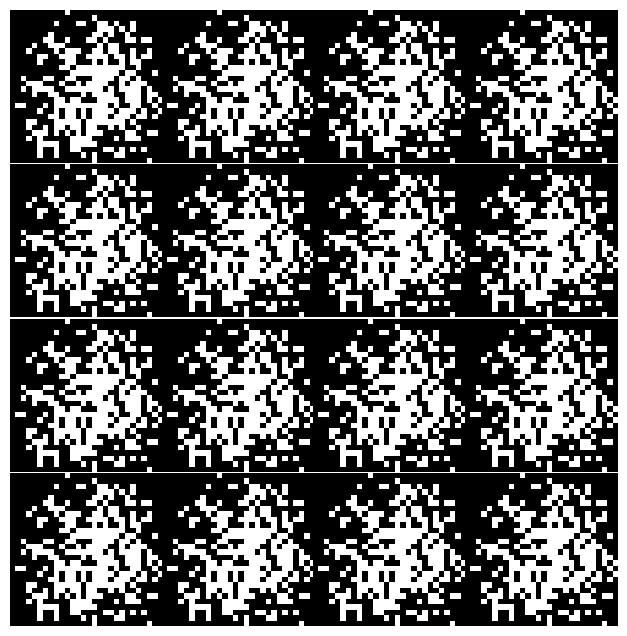

Epoch: 9/10 Losses:
Discriminator: 0.0000; Generator: 17.7254
D(x): 1.0000; D(G(z)): 0.0000


In [56]:
epochs = 10
G_losses = []
D_losses = []

for epoch in range(epochs):
  for real_batch, _ in dataloader:
    real_data = images_to_vectors(real_batch).to(device)

    fake_data = generator(
        noise(real_data.size(0))
    )

    d_error, dpred_real, dpred_fake = (
        train_discriminator(d_optimizer,real_data,fake_data))

    fake_data = generator(noise(fake_data.size(0)))
    g_error = train_generator(g_optimizer, fake_data)

  #mostra as imagens geradas
  imagepath = os.path.join(IMG_DIR, f'{epoch+1},jpg')
  test_images = vectors_to_images(generator(test_noise)).cpu().detach().numpy()
  log_images(test_images, imagepath)

  G_losses.append(g_error)
  D_losses.append(d_error)
  print(f"Epoch: {epoch}/{epochs} Losses:")
  print(f"Discriminator: {d_error:.4f}; Generator: {g_error:.4f}")
  print(f"D(x): {dpred_real.mean():.4f}; D(G(z)): {dpred_fake.mean():.4f}")
